<a href="https://colab.research.google.com/github/ristaangdembay/Bootcamp-DA-AI/blob/main/Capstone_Project_2_Image_Recognition_%26_Classification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project 2: Image Recognition & Classification System  

## Problem Statement:
Build an image classification model using deep learning to accurately classify images in the CIFAR-10 dataset into 10 distinct categories, such as airplanes, cars, and animals. The goal is to develop a robust Convolutional Neural Network (CNN) that can achieve high accuracy in identifying these objects.

## Team Requirements:

- <b>Data Scientist:</b> Skilled in data preprocessing, exploratory data analysis, and CNN architecture design.
- <b>Machine Learning Engineer:</b> Experienced in model training, tuning, and implementing deep learning frameworks like TensorFlow/Keras.
- <b>Deployment Specialist (optional):</b> Knowledgeable in deploying machine learning models as web services or APIs for real-time classification

 we will perform a Image Regconition and cClassification System following the steps belows.

### Step 1. Import Required Libraries

In [1]:
# Import necessary Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt


### Step 2 : Import Datasets
Loading the datasets from CIFAR-10 datasets

In [2]:
# Load and process the CIFAR-10 datasets
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### Step 3: Data Preprocessing


In [3]:
# Normalize pixel values to be beyween 0 and 1
x_train, x_test = x_train/255.0, x_test/255.0

In [4]:
# Class names for CIFAR-10
classes = ['airplanes','automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


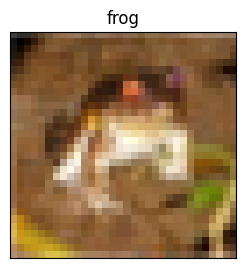

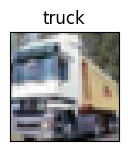

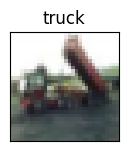

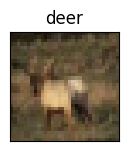

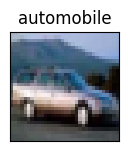

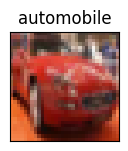

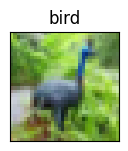

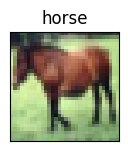

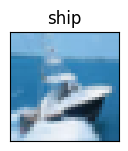

In [5]:
# Display a few sample images with their labels
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i], cmap = plt.cm.binary)
  plt.title(classes[y_train[i][0]])
  plt.show()

### Step 4: Model Development


In [6]:
# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 5: Compile Model


In [7]:
# Compile the model
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [8]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,506 (353.54 KB)

 Trainable params: 90,506 (353.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Train the Model

In [9]:
# Train the model
history = model.fit(x_train, y_train, epochs = 10, validation_data = (x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.3380 - loss: 1.7829 - val_accuracy: 0.5347 - val_loss: 1.2902
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.5755 - loss: 1.1917 - val_accuracy: 0.5986 - val_loss: 1.1219
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - accuracy: 0.6390 - loss: 1.0216 - val_accuracy: 0.6410 - val_loss: 1.0409
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.6812 - loss: 0.9154 - val_accuracy: 0.6425 - val_loss: 1.0274
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7059 - loss: 0.8374 - val_accuracy: 0.6976 - val_loss: 0.8770
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7261 - loss: 0.7750 - val_accuracy: 0.6866 - val_loss: 0.8869
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.7472 - loss: 0.7188 - val_accuracy: 0.7051 - val_loss: 0.8598
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.7658 -

### Step 7: Visaualization

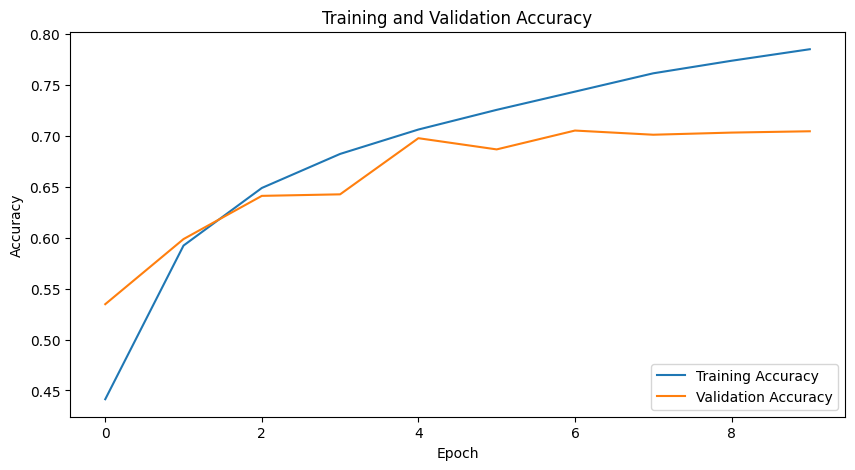

In [10]:
# Plot training and validation accuracy over epochs
plt.figure(figsize = (10,5))
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')
plt.show()

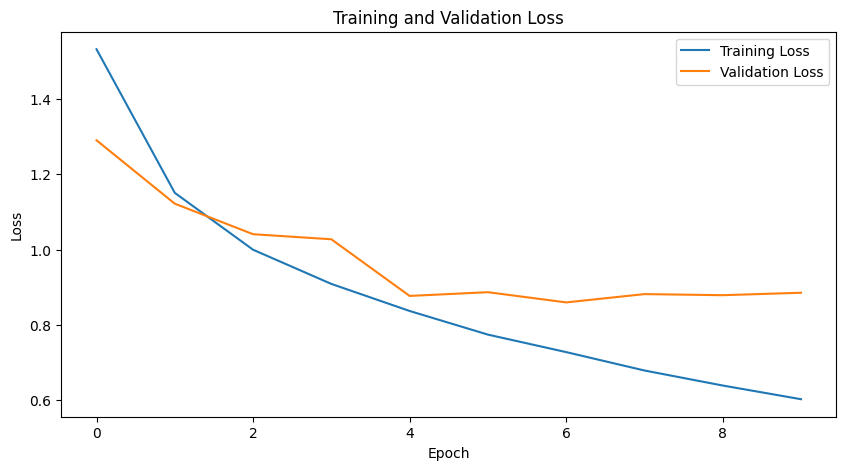

In [13]:
# Plot traing and validation loss over epochs
plt.figure(figsize = (10, 5))
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label ='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

### Step 8: Model Evaluation

In [14]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print(f"\n Test Accuracy: {test_acc:.4f}")


313/313 - 4s - 12ms/step - accuracy: 0.7044 - loss: 0.8854

 Test Accuracy: 0.7044


### Step 9: Make Prediction

In [15]:
# Make prediction on x_test
predictions = model.predict(x_test)



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


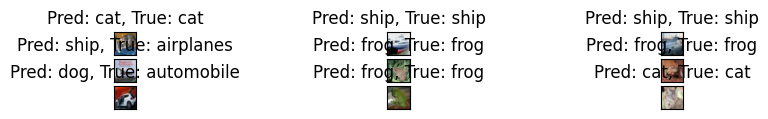

In [17]:
# Display a few test images with their predicted labels
plt.figure(figsize = (10,1))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_test[i], cmap = plt.cm.binary)
  predicted_label = classes[predictions[i].argmax()]
  true_label = classes[y_test[i][0]]
  plt.title(f"Pred: {predicted_label}, True: {true_label}")
plt.show()


# Conclusion

Achieving a test accuracy of 70.44% on CIFAR-10 demonstrates that the CNN was effective at learning features from the images and classifying them into the correct categories. While the performance is solid for a basic CNN architecture on CIFAR-10, there is room for improvement. Possible enhancements include:

- More Complex Architectures: Using deeper networks, such as ResNet or VGG, could enhance accuracy, especially on more challenging datasets like CIFAR-10.

- Regularization Techniques: Techniques like dropout and batch normalization can help reduce overfitting, potentially improving accuracy further.

Overall, this project illustrates the power of CNNs in image classification tasks and serves as a solid foundation for exploring more advanced techniques and architectures in deep learning.






